In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.utils.np_utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from typing import Optional
from PIL import Image
from sklearn.metrics import  precision_score, recall_score, accuracy_score,classification_report ,confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

In [3]:
data = pd.read_csv('D://MEGA BACKUP//PC//Nielit//HAM//hmnist_28_28_RGB.csv')

In [4]:
data.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


**Understanding the data**

The dataset includes 10015 images that are 28 x 28 pixels = 784 pixels As they are RGB images and not gray scale they must be multipled by 3 (R, G, B). In total, there are 2352 pixels. 
* Normalization is achieved by diving by 255
* Data is split into training, validation, and test sets using scikit-learn
* A model to test is created

In [5]:
X = data.drop(columns='label')/255
Y = data['label']

num_rows, num_cols = 28, 28
num_classes = len(set(Y))

In [6]:
X = np.array(X)
X = X.reshape(X.shape[0], num_rows, num_cols, 3)

In [7]:
Y = np.eye(num_classes)[np.array(Y.astype(int)).reshape(-1)]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
#Split the dataset into 80% training and 20% test

In [9]:
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, test_size=0.10, random_state=42)
#Split dataset into 10% of validation from training set

In [10]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',padding = 'Same',input_shape=(num_rows, num_cols, 3)))
model.add(Conv2D(32,kernel_size=(3, 3), activation='relu',padding = 'Same',))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(Conv2D(64, (3, 3), activation='relu',padding = 'Same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.40))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 28, 28, 32)        896       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 64)        18496     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 14, 14, 64)        36928     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 7, 7, 64)         

**Changes to the model**
Early stopping
Changing the drop %
Including a train, test split (+ validation split within training)

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=2)

In [12]:
learning_rate_reduction = ReduceLROnPlateau(monitor='acc', patience=3, verbose=1, factor=0.5, 
                                            min_lr=0.000001, cooldown=3)

In [12]:
model.fit(X_train, y_train, batch_size=64, epochs=50, validation_data=(X_validate, y_validate), callbacks=[learning_rate_reduction])
#10% drop 30% drop 50% drop

Train on 7210 samples, validate on 802 samples
Epoch 1/50
7210/7210 [==============================] - 3s 455us/step - loss: 1.1065 - accuracy: 0.6659 - val_loss: 1.0056 - val_accuracy: 0.6596
Epoch 2/50
1216/7210 [====>.........................] - ETA: 0s - loss: 0.9383 - accuracy: 0.6735

C:\Users\Rishi\anaconda3\envs\Altair\lib\site-packages\keras\callbacks\callbacks.py:1042: RuntimeWarning: Reduce LR on plateau conditioned on metric `acc` which is not available. Available metrics are: val_loss,val_accuracy,loss,accuracy,lr
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


7210/7210 [==============================] - 1s 150us/step - loss: 0.9582 - accuracy: 0.6709 - val_loss: 0.9208 - val_accuracy: 0.6584
Epoch 3/50
7210/7210 [==============================] - 1s 149us/step - loss: 0.9223 - accuracy: 0.6784 - val_loss: 0.8980 - val_accuracy: 0.6683
Epoch 4/50
7210/7210 [==============================] - 1s 150us/step - loss: 0.8881 - accuracy: 0.6817 - val_loss: 0.9045 - val_accuracy: 0.6721
Epoch 5/50
7210/7210 [==============================] - 1s 149us/step - loss: 0.8808 - accuracy: 0.6802 - val_loss: 0.8745 - val_accuracy: 0.6708
Epoch 6/50
7210/7210 [==============================] - 1s 149us/step - loss: 0.8450 - accuracy: 0.6886 - val_loss: 0.8588 - val_accuracy: 0.6908
Epoch 7/50
7210/7210 [==============================] - 1s 149us/step - loss: 0.8360 - accuracy: 0.6935 - val_loss: 0.8679 - val_accuracy: 0.6895
Epoch 8/50
7210/7210 [==============================] - 1s 149us/step - loss: 0.8212 - accuracy: 0.6950 - val_loss: 0.8301 - val_accura

In [13]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print("Test: accuracy = %f  ;  loss = %f" % (accuracy, loss))

2003/2003 [==============================] - 1s 253us/step
Test: accuracy = 0.770844  ;  loss = 0.705764


**Achieve a 93.5% Accuracy CNN**
The following model using image resizing, learning rate reduction, and image data augmentation in order to create a CNN model with 93.5% accuracy. 

In [13]:
import glob
base_skin_dir = os.path.join('..', 'D://MEGA BACKUP//PC//Nielit//HAM//')
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob.glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [14]:
skin_data = pd.read_csv(os.path.join(base_skin_dir, 'HAM10000_metadata.csv'))
skin_data['path'] = skin_data['image_id'].map(imageid_path_dict.get)
skin_data['cell_type'] = skin_data['dx'].map(lesion_type_dict.get) 
skin_data['cell_type_idx'] = pd.Categorical(skin_data['cell_type']).codes
skin_data.sample(3)
#Match the images from the folders and include them in the csv file

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
5125,HAM_0003450,ISIC_0027746,nv,follow_up,40.0,male,trunk,D://MEGA BACKUP//PC//Nielit//HAM\Ham10k\ISIC_0...,Melanocytic nevi,4
3221,HAM_0003344,ISIC_0026399,nv,follow_up,35.0,female,abdomen,D://MEGA BACKUP//PC//Nielit//HAM\Ham10k\ISIC_0...,Melanocytic nevi,4
5791,HAM_0006081,ISIC_0030691,nv,follow_up,45.0,male,upper extremity,D://MEGA BACKUP//PC//Nielit//HAM\Ham10k\ISIC_0...,Melanocytic nevi,4


In [15]:
skin_data.isnull().sum()

lesion_id         0
image_id          0
dx                0
dx_type           0
age              57
sex               0
localization      0
path              0
cell_type         0
cell_type_idx     0
dtype: int64

In [16]:
skin_data['age'].fillna((skin_data['age'].mean()), inplace=True)
#Replace null age with mean age

In [17]:
skin_data['image'] = skin_data['path'].map(lambda x: np.asarray(Image.open(x).resize((28,28))))


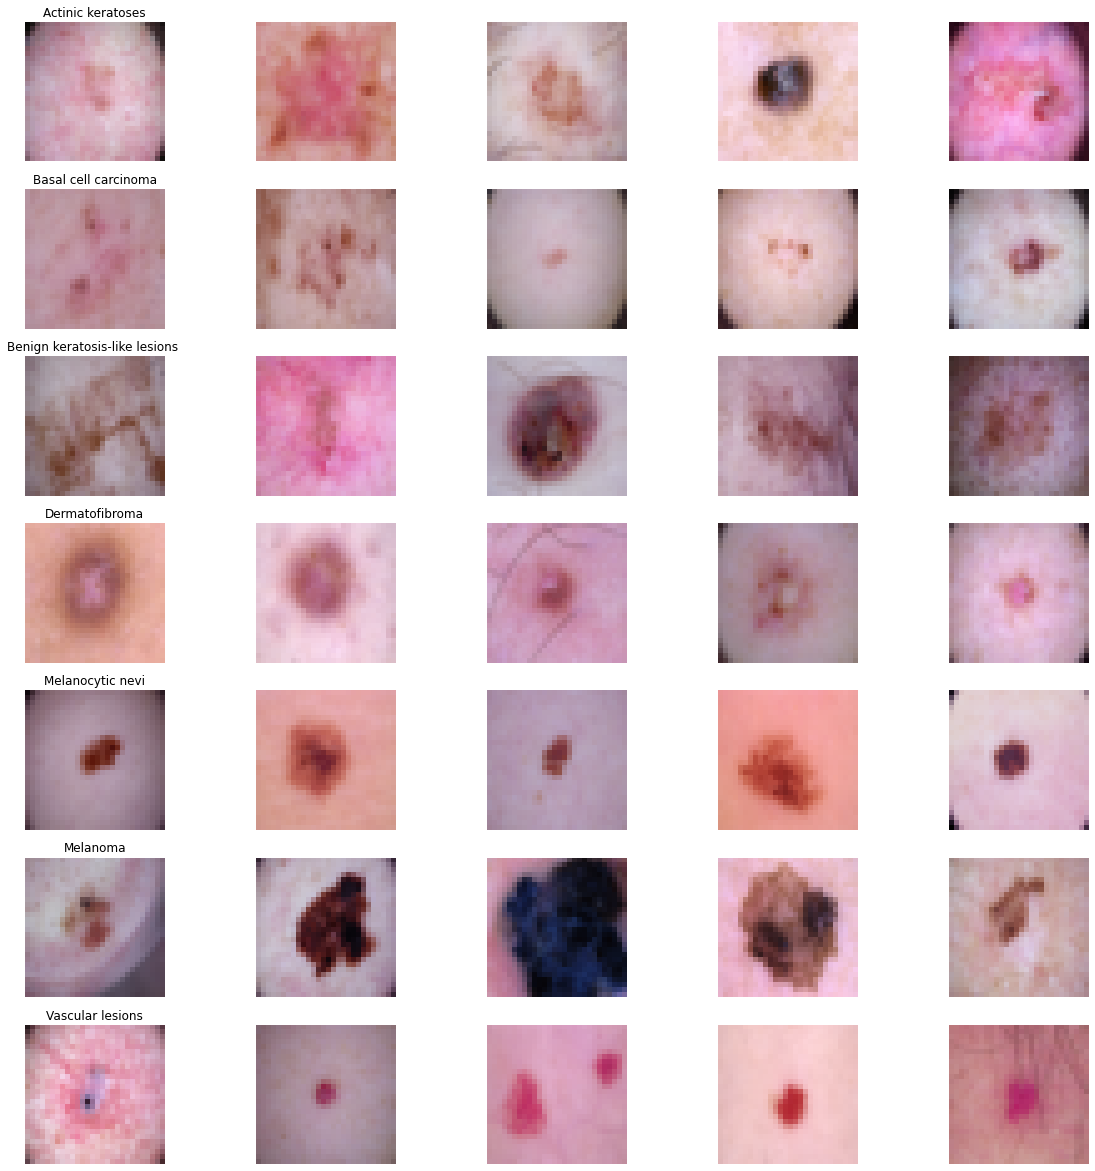

In [19]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, 
                                         skin_data.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=6542).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')

In [18]:
# Checking the image size distribution
skin_data['image'].map(lambda x: x.shape).value_counts()
#Selected 28 x 37 to keep the aspect ratio and see if there is an improvement

(28, 28, 3)    10015
Name: image, dtype: int64

In [19]:
input_shape = (28, 28, 3)
num_classes = 7
model = Sequential([
    Conv2D(32, 3, padding='same', activation='relu', input_shape=input_shape),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, 3, padding='same', activation='relu', input_shape=input_shape),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.4),
    
    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.5),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.55),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 28, 28, 32)        896       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
dropout_4 (Dropout)          (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 14, 14, 64)        18496     
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 14, 14, 64)        36928     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 7, 7, 64)         

**Learning Rate Reduction**
The learning rate refers to how quickly the model can be adapted to the problem. It is a method update the weights during training. Depending on the size, the epochs need to be adjusted accordingly because smaller learning rates make smaller changes, thus need more epochs, while large learning rates result in rapid changes, thus need fewer epochs. 

In [20]:
datagen = ImageDataGenerator(
        featurewise_center=False,  
        samplewise_center=False,  
        featurewise_std_normalization=False,  
        samplewise_std_normalization=False,  
        zca_whitening=False,  
        rotation_range=10,  
        zoom_range = 0.1,
        width_shift_range=0.1,  
        height_shift_range=0.1,  
        horizontal_flip=False,  
        vertical_flip=False)  
datagen.fit(X_train)

**Image Data Augmentation**
A problem with this dataset includes the overfitting of one class. Therefore, in order to combat this I wanted to used ImageDataGenerator, a function in keras, which takes a batch of training images and applies transformations (i.e., rotation, zoom, shifts). After these transformations are completed, this function returns the original data and the transformed data. 
randomly transforming it, and then returning the transformed data, which is used to train the CNN.

In [35]:
epochs = 50 
batch_size = 16
history = model.fit_generator(
    datagen.flow(X_train,y_train, batch_size=batch_size),
    steps_per_epoch=X_train.shape[0] // batch_size,
    epochs=epochs,
    validation_data=(X_validate,y_validate),
    validation_steps=X_validate.shape[0] // batch_size
    ,callbacks=[learning_rate_reduction]
)

Epoch 1/50
450/450 [==============================] - 3s 7ms/step - loss: 0.1245 - accuracy: 0.9494 - val_loss: 0.1542 - val_accuracy: 0.9389
Epoch 2/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1254 - accuracy: 0.9477 - val_loss: 0.1507 - val_accuracy: 0.9398
Epoch 3/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1249 - accuracy: 0.9476 - val_loss: 0.1514 - val_accuracy: 0.9400
Epoch 4/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1251 - accuracy: 0.9481 - val_loss: 0.1514 - val_accuracy: 0.9400
Epoch 5/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1242 - accuracy: 0.9481 - val_loss: 0.1515 - val_accuracy: 0.9394
Epoch 6/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1247 - accuracy: 0.9489 - val_loss: 0.1540 - val_accuracy: 0.9396
Epoch 7/50
450/450 [==============================] - 3s 6ms/step - loss: 0.1261 - accuracy: 0.9470 - val_loss: 0.1512 - val_accuracy: 0.9398
Epoch 

In [36]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print("Test: accuracy = %f  ;  loss = %f" % (accuracy, loss))
#Somehow it improved using the validation train and test that was randomly split
#Early stopping was not good, reduced learning rate better

2003/2003 [==============================] - 0s 186us/step
Test: accuracy = 0.935240  ;  loss = 0.159504


In [37]:
model.save("D://MEGA BACKUP//PC//Nielit//HAM//model.h5")

In [21]:
model.load_weights("D://MEGA BACKUP//PC//Nielit//HAM//model.h5")

In [22]:
predictions = model.predict(X_test, verbose=0)

In [37]:
y_pred = np.argmax(predictions, axis=1)
targetnames = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
y_true = np.argmax(y_test, axis=1)
y_prob=predictions
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_true)

In [38]:
report = classification_report(y_pred,y_true,target_names=targetnames)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

       akiec       0.57      0.40      0.47        98
         bcc       0.60      0.62      0.61        90
         bkl       0.56      0.48      0.52       264
          df       0.04      0.50      0.07         2
         mel       0.88      0.90      0.89      1304
          nv       0.71      0.75      0.73        20
        vasc       0.50      0.50      0.50       225

    accuracy                           0.76      2003
   macro avg       0.55      0.59      0.54      2003
weighted avg       0.76      0.76      0.76      2003



In [39]:
print("Precision: "+ str(precision_score(y_true, y_pred, average='weighted')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='weighted')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
print("weighted Roc score: " + str(roc_auc_score(y_true,y_prob,multi_class='ovr',average='weighted')))

Precision: 0.7701986435027627
Recall: 0.7613579630554169
Accuracy: 0.7613579630554169
weighted Roc score: 0.9194145975544733


In [40]:
print("Precision: "+ str(precision_score(y_true, y_pred, average='macro')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='macro')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
print("Macro Roc score: " + str(roc_auc_score(y_true,y_prob,multi_class='ovr',average='macro')))

Precision: 0.5938274271810018
Recall: 0.5507790074372089
Accuracy: 0.7613579630554169
Macro Roc score: 0.9277646523950838


In [43]:
print("Precision: "+ str(precision_score(y_true, y_pred, average='micro')))
print("Recall: "+ str(recall_score(y_true, y_pred, average='micro')))
print("Accuracy: " + str(accuracy_score(y_true, y_pred)))
tpr={}
fpr={}
roc_auc={}
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
print("Micro Roc score: " + str(roc_auc["micro"]))

Precision: 0.7613579630554169
Recall: 0.7613579630554169
Accuracy: 0.7613579630554169
Micro Roc score: 0.9636605999637587


In [44]:
fpr = {}
tpr = {}
roc_auc = {}
for i in range(7):
    r = roc_auc_score(y_test[:, i], y_prob[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of akiec is: 0.9383271135890173
The ROC AUC score of bcc is: 0.9678883071553228
The ROC AUC score of bkl is: 0.8811440573264145
The ROC AUC score of df is: 0.9150994575045208
The ROC AUC score of mel is: 0.9280780426402329
The ROC AUC score of nv is: 0.9887078948632935
The ROC AUC score of vasc is: 0.8751076936867843
